
# Chilli Cross-Dataset Results Analysis

**Study:** *Cross-Dataset Generalization of Lightweight Deep Learning for Multi-Class Chilli Leaf Disease Classification*

This notebook reads the experiment outputs produced by:

- `run_baselines.py`
- `run_proposed.py`
- `statistical_analysis.py`

It generates manuscript-ready:

- descriptive tables;
- mean ± standard deviation summaries;
- pairwise cross-dataset comparison tables;
- multi-source held-out-domain tables;
- pooled and within-dataset CV tables;
- parameter/efficiency tables;
- training and validation curves;
- confusion matrices;
- per-class metric plots;
- ROC curves;
- model-rank figures;
- Friedman/Wilcoxon/Holm summaries;
- paired-bootstrap and McNemar outputs when available.

> **Important:** Run this notebook from the project root, where `results/` and `data/` are located.


In [1]:

from pathlib import Path
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown
from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
)

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------
# Project paths
# ---------------------------------------------------------------------
PROJECT_ROOT = Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results"
SUMMARY_CSV = RESULTS_DIR / "summary.csv"

FIGURE_DIR = RESULTS_DIR / "manuscript_figures"
TABLE_DIR = RESULTS_DIR / "manuscript_tables"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Project root :", PROJECT_ROOT)
print("Results dir  :", RESULTS_DIR)
print("Figures dir  :", FIGURE_DIR)
print("Tables dir   :", TABLE_DIR)

if not SUMMARY_CSV.exists():
    raise FileNotFoundError(
        f"Missing {SUMMARY_CSV}\n"
        "Run at least one training experiment first."
    )


Project root : C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp
Results dir  : C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results
Figures dir  : C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_figures
Tables dir   : C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_tables


## 1. Load and inspect all run-level results

In [2]:

summary = pd.read_csv(SUMMARY_CSV)

print(f"Loaded {len(summary):,} completed runs.")
print("\nExperiments:")
print(summary["experiment"].value_counts(dropna=False))

print("\nModels:")
print(summary["model_name"].value_counts(dropna=False))

display(summary.head())


Loaded 269 completed runs.

Experiments:
experiment
within_cv      135
pairwise        70
pooled_cv       40
multisource     24
Name: count, dtype: int64

Models:
model_name
mobilenet_v3_small    35
mobilenet_v2          35
shufflenet_v2_x1_0    33
densenet121           29
efficientnet_b0       29
swin_t                29
resnet50              29
chilli_lite_gfnet     29
efficientnet_b4       21
Name: count, dtype: int64


,family,experiment,scenario,source_datasets,target_dataset,exact_target_overlap_removed,model_name,seed,device,pretrained,...,test_macro_f1,test_macro_specificity,test_mcc,test_auc_ovr_macro,test_loss,metrics_path,dataset,fold,n_splits,datasets
0,baselines,multisource,A+B->C,A|B,C,0.0,densenet121,42,cuda,True,...,0.421441,0.808615,0.265483,NaN,1.251372,baselines/densenet121/multisource/A_plus_B_to_...,NaN,NaN,NaN,NaN
1,baselines,multisource,A+C->B,A|C,B,0.0,densenet121,42,cuda,True,...,0.352343,0.864531,0.266150,NaN,2.422299,baselines/densenet121/multisource/A_plus_C_to_...,NaN,NaN,NaN,NaN
2,baselines,multisource,B+C->A,B|C,A,0.0,densenet121,42,cuda,True,...,0.614931,0.907740,0.602351,NaN,1.449542,baselines/densenet121/multisource/B_plus_C_to_...,NaN,NaN,NaN,NaN
3,baselines,multisource,A+B->C,A|B,C,0.0,efficientnet_b0,42,cuda,True,...,0.389126,0.796042,0.209434,NaN,1.368199,baselines/efficientnet_b0/multisource/A_plus_B...,NaN,NaN,NaN,NaN
4,baselines,multisource,A+C->B,A|C,B,0.0,efficientnet_b0,42,cuda,True,...,0.511160,0.905710,0.465960,NaN,1.768436,baselines/efficientnet_b0/multisource/A_plus_C...,NaN,NaN,NaN,NaN


In [3]:

# Stable display names for manuscript tables.
MODEL_DISPLAY = {
    "mobilenet_v2": "MobileNetV2",
    "mobilenet_v3_small": "MobileNetV3-Small",
    "shufflenet_v2_x1_0": "ShuffleNetV2",
    "efficientnet_b0": "EfficientNet-B0",
    "efficientnet_b4": "EfficientNet-B4",
    "resnet50": "ResNet50",
    "densenet121": "DenseNet121",
    "swin_t": "Swin-Tiny",
    "chilli_lite_gfnet": "ChilliLite-GFNet",
}

CANONICAL_MODEL_ORDER = [
    "mobilenet_v2",
    "mobilenet_v3_small",
    "shufflenet_v2_x1_0",
    "efficientnet_b0",
    "efficientnet_b4",
    "resnet50",
    "densenet121",
    "swin_t",
    "chilli_lite_gfnet",
]

summary["model_display"] = summary["model_name"].map(MODEL_DISPLAY).fillna(summary["model_name"])

metric_cols = [c for c in summary.columns if c.startswith("test_")]
print("Available test metrics:")
print(metric_cols)


Available test metrics:
['test_accuracy', 'test_balanced_accuracy', 'test_macro_precision', 'test_macro_recall', 'test_macro_f1', 'test_macro_specificity', 'test_mcc', 'test_auc_ovr_macro', 'test_loss']


## 2. Data completeness and experiment coverage

In [4]:

coverage = (
    summary.groupby(["experiment", "scenario", "model_display"])
    .size()
    .rename("completed_runs")
    .reset_index()
    .sort_values(["experiment", "scenario", "model_display"])
)

display(coverage)

coverage.to_csv(TABLE_DIR / "experiment_coverage.csv", index=False)
print("Saved:", TABLE_DIR / "experiment_coverage.csv")


,experiment,scenario,model_display,completed_runs
0,multisource,A+B->C,ChilliLite-GFNet,1
1,multisource,A+B->C,DenseNet121,1
2,multisource,A+B->C,EfficientNet-B0,1
3,multisource,A+B->C,MobileNetV2,1
4,multisource,A+B->C,MobileNetV3-Small,1
...,...,...,...,...
108,within_cv,C_within,MobileNetV2,5
109,within_cv,C_within,MobileNetV3-Small,5
110,within_cv,C_within,ResNet50,5
111,within_cv,C_within,ShuffleNetV2,5


Saved: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_tables\experiment_coverage.csv



## 3. Generic descriptive summary

For each scenario and model, the notebook reports:

- number of completed runs;
- mean;
- standard deviation;
- median;
- 95% confidence interval based on the Student-\(t\) distribution.

For the manuscript, **mean ± SD** is the primary summary for repeated folds/seeds.


In [5]:

try:
    from scipy.stats import t
except ImportError as exc:
    raise ImportError("Install SciPy: pip install scipy") from exc

def descriptive_summary(df: pd.DataFrame, metric: str) -> pd.DataFrame:
    rows = []
    for (experiment, scenario, model), g in df.groupby(
        ["experiment", "scenario", "model_display"]
    ):
        values = g[metric].dropna().astype(float).to_numpy()
        if len(values) == 0:
            continue

        n = len(values)
        mean = float(values.mean())
        std = float(values.std(ddof=1)) if n > 1 else np.nan
        sem = std / math.sqrt(n) if n > 1 else np.nan
        ci_half = (
            float(t.ppf(0.975, n - 1) * sem)
            if n > 1 and np.isfinite(sem)
            else np.nan
        )

        rows.append({
            "experiment": experiment,
            "scenario": scenario,
            "model": model,
            "n": n,
            "mean": mean,
            "std": std,
            "median": float(np.median(values)),
            "ci95_low": mean - ci_half if np.isfinite(ci_half) else np.nan,
            "ci95_high": mean + ci_half if np.isfinite(ci_half) else np.nan,
        })

    return pd.DataFrame(rows)

macro_f1_desc = descriptive_summary(summary, "test_macro_f1")
display(macro_f1_desc.head(20))

macro_f1_desc.to_csv(TABLE_DIR / "macro_f1_descriptive_summary.csv", index=False)


,experiment,scenario,model,n,mean,std,median,ci95_low,ci95_high
0,multisource,A+B->C,ChilliLite-GFNet,1,0.236038,NaN,0.236038,NaN,NaN
1,multisource,A+B->C,DenseNet121,1,0.421441,NaN,0.421441,NaN,NaN
2,multisource,A+B->C,EfficientNet-B0,1,0.389126,NaN,0.389126,NaN,NaN
3,multisource,A+B->C,MobileNetV2,1,0.342144,NaN,0.342144,NaN,NaN
4,multisource,A+B->C,MobileNetV3-Small,1,0.323014,NaN,0.323014,NaN,NaN
5,multisource,A+B->C,ResNet50,1,0.475834,NaN,0.475834,NaN,NaN
6,multisource,A+B->C,ShuffleNetV2,1,0.499919,NaN,0.499919,NaN,NaN
7,multisource,A+B->C,Swin-Tiny,1,0.509144,NaN,0.509144,NaN,NaN
8,multisource,A+C->B,ChilliLite-GFNet,1,0.172982,NaN,0.172982,NaN,NaN
9,multisource,A+C->B,DenseNet121,1,0.352343,NaN,0.352343,NaN,NaN


## 4. Helper functions for manuscript tables

In [6]:

def mean_std_text(values, digits=4):
    values = pd.Series(values).dropna().astype(float)
    if len(values) == 0:
        return "--"
    if len(values) == 1:
        return f"{values.iloc[0]:.{digits}f}"
    return f"{values.mean():.{digits}f} ± {values.std(ddof=1):.{digits}f}"


def make_metric_table(
    df: pd.DataFrame,
    experiment: str,
    metrics=("test_accuracy", "test_macro_f1", "test_mcc", "test_auc_ovr_macro"),
    digits=4,
):
    x = df[df["experiment"] == experiment].copy()
    if x.empty:
        return pd.DataFrame()

    rows = []
    for (scenario, model), g in x.groupby(["scenario", "model_display"]):
        row = {
            "Scenario": scenario,
            "Model": model,
            "Runs": len(g),
        }
        for metric in metrics:
            if metric in g.columns:
                row[metric] = mean_std_text(g[metric], digits=digits)
        if "parameters" in g.columns:
            row["Parameters (M)"] = g["parameters"].dropna().mean() / 1e6
        rows.append(row)

    return pd.DataFrame(rows).sort_values(["Scenario", "Model"]).reset_index(drop=True)


def save_table(df: pd.DataFrame, filename: str):
    path = TABLE_DIR / filename
    df.to_csv(path, index=False)
    print("Saved:", path)
    return path


## 5. Within-dataset 5-fold CV table

In [7]:

within_table = make_metric_table(summary, "within_cv")
if within_table.empty:
    print("No within_cv results found yet.")
else:
    display(within_table)
    save_table(within_table, "within_cv_results.csv")


,Scenario,Model,Runs,test_accuracy,test_macro_f1,test_mcc,test_auc_ovr_macro,Parameters (M)
0,A_within,ChilliLite-GFNet,5,0.9879 ± 0.0071,0.9795 ± 0.0120,0.9841 ± 0.0094,0.9981 ± 0.0021,1.154679
1,A_within,DenseNet121,5,0.9909 ± 0.0103,0.9826 ± 0.0200,0.9882 ± 0.0132,--,6.958981
2,A_within,EfficientNet-B0,5,0.9945 ± 0.0050,0.9903 ± 0.0089,0.9929 ± 0.0065,--,4.013953
3,A_within,EfficientNet-B4,5,0.9933 ± 0.0045,0.9888 ± 0.0079,0.9913 ± 0.0058,--,17.557581
4,A_within,MobileNetV2,5,0.9909 ± 0.0071,0.9850 ± 0.0145,0.9882 ± 0.0091,--,2.230277
5,A_within,MobileNetV3-Small,5,0.9873 ± 0.0114,0.9791 ± 0.0184,0.9834 ± 0.0148,0.9999,1.522981
6,A_within,ResNet50,5,0.9873 ± 0.0136,0.9804 ± 0.0212,0.9834 ± 0.0177,--,23.518277
7,A_within,ShuffleNetV2,5,0.9939 ± 0.0030,0.9900 ± 0.0051,0.9921 ± 0.0040,0.9999,1.258729
8,A_within,Swin-Tiny,5,0.9903 ± 0.0089,0.9823 ± 0.0163,0.9874 ± 0.0117,--,27.523199
9,B_within,ChilliLite-GFNet,5,0.9768 ± 0.0050,0.9783 ± 0.0049,0.9720 ± 0.0060,--,1.154760


Saved: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_tables\within_cv_results.csv


## 6. Bidirectional pairwise cross-dataset table

In [8]:

pairwise_table = make_metric_table(summary, "pairwise")
if pairwise_table.empty:
    print("No pairwise results found yet.")
else:
    display(pairwise_table)
    save_table(pairwise_table, "pairwise_cross_dataset_results.csv")


,Scenario,Model,Runs,test_accuracy,test_macro_f1,test_mcc,test_auc_ovr_macro,Parameters (M)
0,A->B,ChilliLite-GFNet,1,0.4399,0.3965,0.3815,--,1.154679
1,A->B,DenseNet121,1,0.4541,0.3839,0.3776,--,6.958981
2,A->B,EfficientNet-B0,1,0.3515,0.2641,0.2264,--,4.013953
3,A->B,EfficientNet-B4,1,0.4299,0.3516,0.3481,--,17.557581
4,A->B,MobileNetV2,2,0.4395 ± 0.0308,0.3725 ± 0.0382,0.3500 ± 0.0385,--,2.230277
5,A->B,MobileNetV3-Small,2,0.4249 ± 0.0165,0.3659 ± 0.0347,0.3293 ± 0.0250,--,1.522981
6,A->B,ResNet50,1,0.4558,0.4022,0.3943,--,23.518277
7,A->B,ShuffleNetV2,2,0.4723 ± 0.0163,0.4079 ± 0.0205,0.3971 ± 0.0246,--,1.258729
8,A->B,Swin-Tiny,1,0.5415,0.5167,0.5017,--,27.523199
9,A->C,ChilliLite-GFNet,1,0.5425,0.4888,0.2237,--,1.154517


Saved: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_tables\pairwise_cross_dataset_results.csv


## 7. Multi-source held-out-domain table

In [9]:

multisource_table = make_metric_table(summary, "multisource")
if multisource_table.empty:
    print("No multisource results found yet.")
else:
    display(multisource_table)
    save_table(multisource_table, "multisource_results.csv")


,Scenario,Model,Runs,test_accuracy,test_macro_f1,test_mcc,test_auc_ovr_macro,Parameters (M)
0,A+B->C,ChilliLite-GFNet,1,0.3301,0.2360,0.1368,--,1.154598
1,A+B->C,DenseNet121,1,0.5763,0.4214,0.2655,--,6.957956
2,A+B->C,EfficientNet-B0,1,0.5474,0.3891,0.2094,--,4.012672
3,A+B->C,MobileNetV2,1,0.4840,0.3421,0.2463,--,2.228996
4,A+B->C,MobileNetV3-Small,1,0.4387,0.3230,0.1581,--,1.521956
5,A+B->C,ResNet50,1,0.5908,0.4758,0.3065,--,23.516228
6,A+B->C,ShuffleNetV2,1,0.5552,0.4999,0.3019,--,1.257704
7,A+B->C,Swin-Tiny,1,0.5788,0.5091,0.3859,--,27.522430
8,A+C->B,ChilliLite-GFNet,1,0.2340,0.1730,0.1006,--,1.154760
9,A+C->B,DenseNet121,1,0.3567,0.3523,0.2662,--,6.960006


Saved: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_tables\multisource_results.csv


## 8. Pooled 5-fold CV table

In [10]:

pooled_table = make_metric_table(summary, "pooled_cv")
if pooled_table.empty:
    print("No pooled_cv results found yet.")
else:
    display(pooled_table)
    save_table(pooled_table, "pooled_cv_results.csv")


,Scenario,Model,Runs,test_accuracy,test_macro_f1,test_mcc,test_auc_ovr_macro,Parameters (M)
0,A+B+C_pooled,ChilliLite-GFNet,5,0.9527 ± 0.0051,0.9569 ± 0.0046,0.9422 ± 0.0062,--,1.154760
1,A+B+C_pooled,DenseNet121,5,0.9552 ± 0.0069,0.9599 ± 0.0060,0.9454 ± 0.0084,--,6.960006
2,A+B+C_pooled,EfficientNet-B0,5,0.9653 ± 0.0035,0.9688 ± 0.0027,0.9577 ± 0.0043,--,4.015234
3,A+B+C_pooled,MobileNetV2,5,0.9590 ± 0.0026,0.9630 ± 0.0017,0.9499 ± 0.0033,--,2.231558
4,A+B+C_pooled,MobileNetV3-Small,5,0.9613 ± 0.0015,0.9660 ± 0.0009,0.9527 ± 0.0019,--,1.524006
5,A+B+C_pooled,ResNet50,5,0.9556 ± 0.0076,0.9600 ± 0.0064,0.9458 ± 0.0093,--,23.520326
6,A+B+C_pooled,ShuffleNetV2,5,0.9551 ± 0.0067,0.9599 ± 0.0056,0.9452 ± 0.0083,--,1.259754
7,A+B+C_pooled,Swin-Tiny,5,0.9587 ± 0.0121,0.9633 ± 0.0106,0.9496 ± 0.0148,--,27.523968


Saved: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_tables\pooled_cv_results.csv


## 9. Best model per scenario

In [11]:

def best_model_per_scenario(df, experiment, metric="test_macro_f1"):
    x = df[df["experiment"] == experiment].copy()
    if x.empty:
        return pd.DataFrame()

    agg = (
        x.groupby(["scenario", "model_display"])[metric]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    idx = agg.groupby("scenario")["mean"].idxmax()
    best = agg.loc[idx].sort_values("scenario").reset_index(drop=True)
    best = best.rename(columns={
        "model_display": "best_model",
        "mean": f"{metric}_mean",
        "std": f"{metric}_std",
        "count": "runs",
    })
    return best

for exp in ["within_cv", "pairwise", "multisource", "pooled_cv"]:
    best = best_model_per_scenario(summary, exp)
    if not best.empty:
        print(f"\nBest model by Macro-F1: {exp}")
        display(best)
        save_table(best, f"best_model_{exp}.csv")



Best model by Macro-F1: within_cv


,scenario,best_model,test_macro_f1_mean,test_macro_f1_std,runs
0,A_within,EfficientNet-B0,0.990313,0.008899,5
1,B_within,EfficientNet-B0,0.986189,0.002057,5
2,C_within,EfficientNet-B0,0.840488,0.018260,5


Saved: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_tables\best_model_within_cv.csv

Best model by Macro-F1: pairwise


,scenario,best_model,test_macro_f1_mean,test_macro_f1_std,runs
0,A->B,Swin-Tiny,0.516743,NaN,1
1,A->C,Swin-Tiny,0.507078,NaN,1
2,B->A,EfficientNet-B4,0.695427,NaN,1
3,B->C,EfficientNet-B4,0.394363,NaN,1
4,C->A,EfficientNet-B4,0.784142,NaN,1
5,C->B,EfficientNet-B4,0.631252,NaN,1


Saved: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_tables\best_model_pairwise.csv

Best model by Macro-F1: multisource


,scenario,best_model,test_macro_f1_mean,test_macro_f1_std,runs
0,A+B->C,Swin-Tiny,0.509144,NaN,1
1,A+C->B,ResNet50,0.624778,NaN,1
2,B+C->A,DenseNet121,0.614931,NaN,1


Saved: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_tables\best_model_multisource.csv

Best model by Macro-F1: pooled_cv


,scenario,best_model,test_macro_f1_mean,test_macro_f1_std,runs
0,A+B+C_pooled,EfficientNet-B0,0.968809,0.002721,5


Saved: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_tables\best_model_pooled_cv.csv



## 10. Pairwise cross-dataset Macro-F1 figure

This grouped bar chart compares models across the six bidirectional transfer directions.
Error bars show standard deviation when multiple seeds are available.


Saved: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_figures\pairwise_macro_f1.png


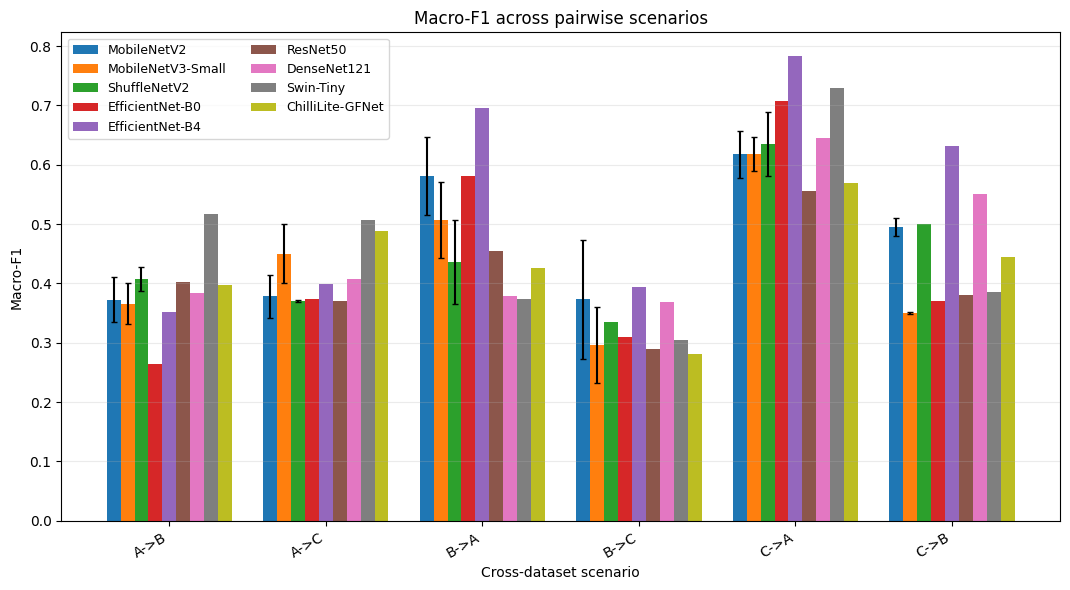

In [12]:

def grouped_bar_by_scenario(
    df,
    experiment,
    metric="test_macro_f1",
    ylabel="Macro-F1",
    filename=None,
):
    x = df[df["experiment"] == experiment].copy()
    if x.empty:
        print(f"No {experiment} results found.")
        return

    agg = (
        x.groupby(["scenario", "model_display"])[metric]
        .agg(["mean", "std"])
        .reset_index()
    )

    scenarios = list(agg["scenario"].drop_duplicates())
    models = [m for m in [MODEL_DISPLAY.get(k, k) for k in CANONICAL_MODEL_ORDER]
              if m in set(agg["model_display"])]

    width = 0.8 / max(1, len(models))
    xpos = np.arange(len(scenarios))

    fig, ax = plt.subplots(figsize=(max(10, len(scenarios) * 1.8), 6))

    for i, model in enumerate(models):
        vals = []
        errs = []
        for scenario in scenarios:
            row = agg[
                (agg["scenario"] == scenario)
                & (agg["model_display"] == model)
            ]
            vals.append(row["mean"].iloc[0] if len(row) else np.nan)
            errs.append(row["std"].iloc[0] if len(row) else np.nan)

        ax.bar(
            xpos + (i - (len(models) - 1) / 2) * width,
            vals,
            width=width,
            yerr=errs,
            capsize=2,
            label=model,
        )

    ax.set_xticks(xpos)
    ax.set_xticklabels(scenarios, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Cross-dataset scenario")
    ax.set_title(f"{ylabel} across {experiment} scenarios")
    ax.legend(ncol=2, fontsize=9)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()

    if filename:
        path = FIGURE_DIR / filename
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print("Saved:", path)

    plt.show()


grouped_bar_by_scenario(
    summary,
    experiment="pairwise",
    metric="test_macro_f1",
    ylabel="Macro-F1",
    filename="pairwise_macro_f1.png",
)


## 11. Multi-source Macro-F1 figure

Saved: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_figures\multisource_macro_f1.png


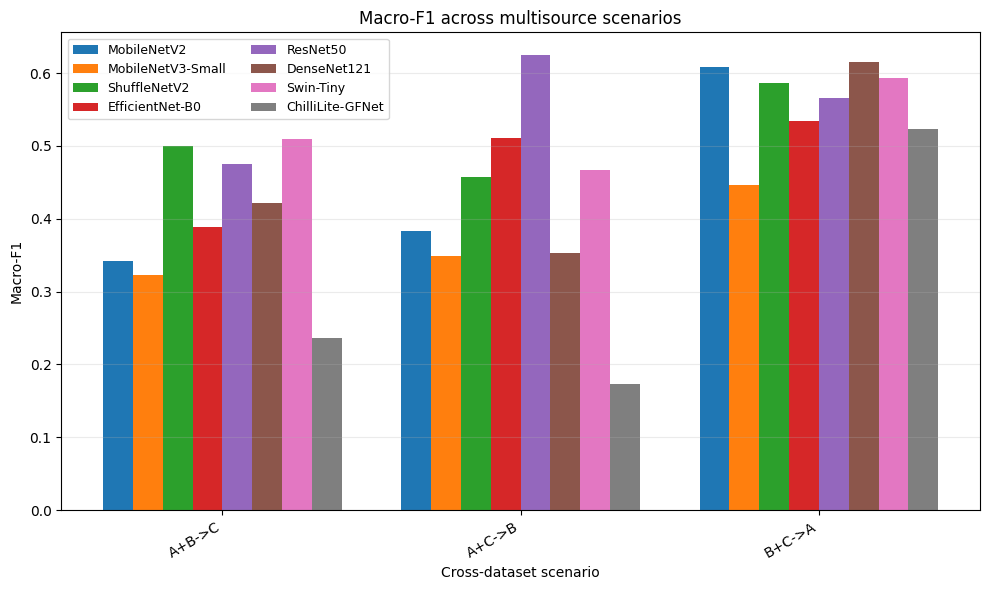

In [13]:

grouped_bar_by_scenario(
    summary,
    experiment="multisource",
    metric="test_macro_f1",
    ylabel="Macro-F1",
    filename="multisource_macro_f1.png",
)



## 12. Cross-dataset transfer matrix

For a selected model, this figure visualizes directional transfer performance.
Rows are source datasets and columns are target datasets.


Saved: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_figures\transfer_matrix_chilli_lite_gfnet.png


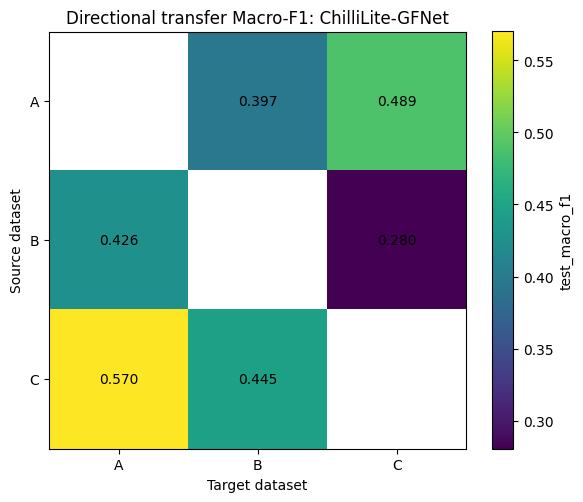

In [14]:

def transfer_matrix(
    df,
    model_name,
    metric="test_macro_f1",
    filename=None,
):
    x = df[
        (df["experiment"] == "pairwise")
        & (df["model_name"] == model_name)
    ].copy()

    if x.empty:
        print(f"No pairwise results for {model_name}.")
        return

    agg = x.groupby("scenario")[metric].mean()

    datasets = ["A", "B", "C"]
    mat = np.full((3, 3), np.nan)

    for i, src in enumerate(datasets):
        for j, tgt in enumerate(datasets):
            if src == tgt:
                continue
            scenario = f"{src}->{tgt}"
            if scenario in agg.index:
                mat[i, j] = agg.loc[scenario]

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(mat)

    ax.set_xticks(range(3))
    ax.set_yticks(range(3))
    ax.set_xticklabels(datasets)
    ax.set_yticklabels(datasets)
    ax.set_xlabel("Target dataset")
    ax.set_ylabel("Source dataset")
    ax.set_title(f"Directional transfer Macro-F1: {MODEL_DISPLAY.get(model_name, model_name)}")

    for i in range(3):
        for j in range(3):
            if np.isfinite(mat[i, j]):
                ax.text(j, i, f"{mat[i, j]:.3f}", ha="center", va="center")

    fig.colorbar(im, ax=ax, label=metric)
    fig.tight_layout()

    if filename:
        path = FIGURE_DIR / filename
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print("Saved:", path)

    plt.show()


# Change this model if needed.
SELECTED_MODEL = (
    "chilli_lite_gfnet"
    if "chilli_lite_gfnet" in set(summary["model_name"])
    else "mobilenet_v2"
)

transfer_matrix(
    summary,
    SELECTED_MODEL,
    filename=f"transfer_matrix_{SELECTED_MODEL}.png",
)


## 13. Accuracy–efficiency trade-off

Saved: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_figures\pairwise_accuracy_efficiency.png


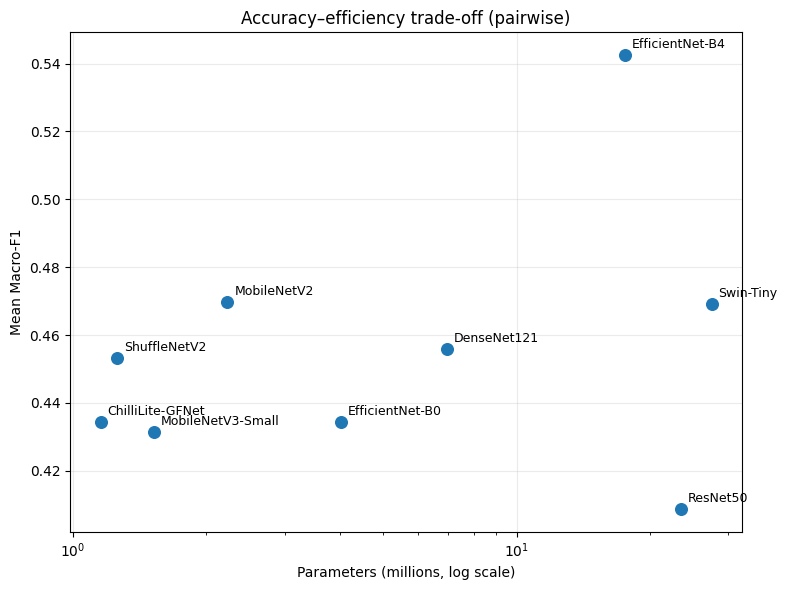

,model_name,model_display,metric_mean,parameters,elapsed_seconds,parameters_m
3,efficientnet_b4,EfficientNet-B4,0.542508,17555788.0,390.383355,17.555788
4,mobilenet_v2,MobileNetV2,0.469622,2228996.0,268.493921,2.228996
8,swin_t,Swin-Tiny,0.469273,27522430.0,367.785572,27.522430
1,densenet121,DenseNet121,0.455822,6957956.0,328.210283,6.957956
7,shufflenet_v2_x1_0,ShuffleNetV2,0.453310,1257704.0,313.619073,1.257704
0,chilli_lite_gfnet,ChilliLite-GFNet,0.434506,1154598.0,371.507709,1.154598
2,efficientnet_b0,EfficientNet-B0,0.434274,4012672.0,314.785211,4.012672
5,mobilenet_v3_small,MobileNetV3-Small,0.431376,1521956.0,305.794307,1.521956
6,resnet50,ResNet50,0.408638,23516228.0,297.130771,23.516228


In [15]:

def efficiency_scatter(
    df,
    experiment="pairwise",
    metric="test_macro_f1",
    filename=None,
):
    x = df[df["experiment"] == experiment].copy()
    if x.empty:
        print(f"No {experiment} results found.")
        return

    agg = (
        x.groupby(["model_name", "model_display"])
        .agg(
            metric_mean=(metric, "mean"),
            parameters=("parameters", "mean"),
            elapsed_seconds=("elapsed_seconds", "mean"),
        )
        .reset_index()
    )
    agg["parameters_m"] = agg["parameters"] / 1e6

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(
        agg["parameters_m"],
        agg["metric_mean"],
        s=70,
    )

    for _, row in agg.iterrows():
        ax.annotate(
            row["model_display"],
            (row["parameters_m"], row["metric_mean"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
        )

    ax.set_xscale("log")
    ax.set_xlabel("Parameters (millions, log scale)")
    ax.set_ylabel("Mean Macro-F1")
    ax.set_title(f"Accuracy–efficiency trade-off ({experiment})")
    ax.grid(alpha=0.25)
    fig.tight_layout()

    if filename:
        path = FIGURE_DIR / filename
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print("Saved:", path)

    plt.show()

    return agg.sort_values("metric_mean", ascending=False)


efficiency_table = efficiency_scatter(
    summary,
    experiment="pairwise",
    metric="test_macro_f1",
    filename="pairwise_accuracy_efficiency.png",
)

if efficiency_table is not None:
    display(efficiency_table)
    efficiency_table.to_csv(TABLE_DIR / "pairwise_efficiency_summary.csv", index=False)



## 14. Select one run for detailed inspection

The next cells inspect:

- `history.csv`
- `confusion_matrix.csv`
- `per_class_metrics.csv`
- `predictions.csv`

Change the selectors below to any completed run.


In [16]:

# ---------------------------------------------------------------------
# Run selector
# ---------------------------------------------------------------------
DETAIL_EXPERIMENT = "pairwise"
DETAIL_SCENARIO = "A->B"
DETAIL_MODEL = SELECTED_MODEL

detail_candidates = summary[
    (summary["experiment"] == DETAIL_EXPERIMENT)
    & (summary["scenario"] == DETAIL_SCENARIO)
    & (summary["model_name"] == DETAIL_MODEL)
].copy()

if detail_candidates.empty:
    print("Requested detailed run not found.")
    print("Available examples:")
    display(
        summary[
            ["experiment", "scenario", "model_name", "seed", "metrics_path"]
        ].head(20)
    )
    DETAIL_RUN = None
else:
    DETAIL_RUN = detail_candidates.iloc[0]
    display(detail_candidates)
    print("Selected metrics file:", DETAIL_RUN["metrics_path"])


,family,experiment,scenario,source_datasets,target_dataset,exact_target_overlap_removed,model_name,seed,device,pretrained,...,test_macro_specificity,test_mcc,test_auc_ovr_macro,test_loss,metrics_path,dataset,fold,n_splits,datasets,model_display
260,proposed,pairwise,A->B,A,B,0.0,chilli_lite_gfnet,42,cuda,True,...,0.859481,0.381504,NaN,2.074108,proposed/chilli_lite_gfnet/pairwise/A_to_B/see...,NaN,NaN,NaN,NaN,ChilliLite-GFNet


Selected metrics file: proposed/chilli_lite_gfnet/pairwise/A_to_B/seed_42/metrics.json


## 15. Training and validation history

In [17]:

def run_dir_from_summary_row(row):
    return Path(row["metrics_path"]).resolve().parent

if DETAIL_RUN is not None:
    run_dir = run_dir_from_summary_row(DETAIL_RUN)
    history_path = run_dir / "history.csv"

    if history_path.exists():
        history = pd.read_csv(history_path)
        display(history.head())

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(history["epoch"], history["train_loss"], label="Train loss")
        ax.plot(history["epoch"], history["val_loss"], label="Validation loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title(
            f"Loss convergence: {MODEL_DISPLAY.get(DETAIL_MODEL, DETAIL_MODEL)} "
            f"({DETAIL_SCENARIO})"
        )
        ax.legend()
        ax.grid(alpha=0.25)
        fig.tight_layout()

        path = FIGURE_DIR / f"history_loss_{DETAIL_MODEL}_{DETAIL_SCENARIO.replace('->','_to_')}.png"
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print("Saved:", path)
        plt.show()

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(history["epoch"], history["train_macro_f1"], label="Train Macro-F1")
        ax.plot(history["epoch"], history["val_macro_f1"], label="Validation Macro-F1")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Macro-F1")
        ax.set_title(
            f"Macro-F1 convergence: {MODEL_DISPLAY.get(DETAIL_MODEL, DETAIL_MODEL)} "
            f"({DETAIL_SCENARIO})"
        )
        ax.legend()
        ax.grid(alpha=0.25)
        fig.tight_layout()

        path = FIGURE_DIR / f"history_f1_{DETAIL_MODEL}_{DETAIL_SCENARIO.replace('->','_to_')}.png"
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print("Saved:", path)
        plt.show()
    else:
        print("Missing:", history_path)


Missing: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\proposed\chilli_lite_gfnet\pairwise\A_to_B\seed_42\history.csv


## 16. Confusion matrix

In [18]:

if DETAIL_RUN is not None:
    run_dir = run_dir_from_summary_row(DETAIL_RUN)
    cm_path = run_dir / "confusion_matrix.csv"

    if cm_path.exists():
        cm_df = pd.read_csv(cm_path, index_col=0)
        display(cm_df)

        cm = cm_df.to_numpy(dtype=float)
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_norm = np.divide(
            cm,
            row_sums,
            out=np.zeros_like(cm, dtype=float),
            where=row_sums != 0,
        )

        fig, ax = plt.subplots(figsize=(8, 7))
        im = ax.imshow(cm_norm)

        labels = list(cm_df.index)
        ax.set_xticks(range(len(labels)))
        ax.set_yticks(range(len(labels)))
        ax.set_xticklabels(labels, rotation=45, ha="right")
        ax.set_yticklabels(labels)
        ax.set_xlabel("Predicted class")
        ax.set_ylabel("True class")
        ax.set_title(
            f"Normalized confusion matrix: "
            f"{MODEL_DISPLAY.get(DETAIL_MODEL, DETAIL_MODEL)} ({DETAIL_SCENARIO})"
        )

        for i in range(cm_norm.shape[0]):
            for j in range(cm_norm.shape[1]):
                ax.text(
                    j, i,
                    f"{cm_norm[i, j]:.2f}\n({int(cm[i, j])})",
                    ha="center",
                    va="center",
                    fontsize=8,
                )

        fig.colorbar(im, ax=ax, label="Row-normalized proportion")
        fig.tight_layout()

        path = FIGURE_DIR / f"confusion_{DETAIL_MODEL}_{DETAIL_SCENARIO.replace('->','_to_')}.png"
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print("Saved:", path)
        plt.show()
    else:
        print("Missing:", cm_path)


Missing: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\proposed\chilli_lite_gfnet\pairwise\A_to_B\seed_42\confusion_matrix.csv


## 17. Per-class metrics

In [19]:

if DETAIL_RUN is not None:
    run_dir = run_dir_from_summary_row(DETAIL_RUN)
    per_class_path = run_dir / "per_class_metrics.csv"

    if per_class_path.exists():
        per_class = pd.read_csv(per_class_path)
        display(per_class)

        metrics_to_plot = [
            "precision",
            "recall_sensitivity",
            "specificity",
            "f1",
        ]
        available = [m for m in metrics_to_plot if m in per_class.columns]

        x = np.arange(len(per_class))
        width = 0.8 / max(1, len(available))

        fig, ax = plt.subplots(figsize=(max(9, len(per_class) * 1.6), 6))

        for i, metric in enumerate(available):
            ax.bar(
                x + (i - (len(available) - 1) / 2) * width,
                per_class[metric],
                width=width,
                label=metric.replace("_", " ").title(),
            )

        ax.set_xticks(x)
        ax.set_xticklabels(per_class["class_name"], rotation=35, ha="right")
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Score")
        ax.set_title(
            f"Per-class performance: "
            f"{MODEL_DISPLAY.get(DETAIL_MODEL, DETAIL_MODEL)} ({DETAIL_SCENARIO})"
        )
        ax.legend()
        ax.grid(axis="y", alpha=0.25)
        fig.tight_layout()

        path = FIGURE_DIR / f"per_class_{DETAIL_MODEL}_{DETAIL_SCENARIO.replace('->','_to_')}.png"
        fig.savefig(path, dpi=300, bbox_inches="tight")
        print("Saved:", path)
        plt.show()
    else:
        print("Missing:", per_class_path)


Missing: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\proposed\chilli_lite_gfnet\pairwise\A_to_B\seed_42\per_class_metrics.csv


## 18. Multi-class ROC curves

In [20]:

if DETAIL_RUN is not None:
    run_dir = run_dir_from_summary_row(DETAIL_RUN)
    pred_path = run_dir / "predictions.csv"

    if pred_path.exists():
        pred = pd.read_csv(pred_path)
        prob_cols = [c for c in pred.columns if c.startswith("prob_")]

        if not prob_cols:
            print("No probability columns found.")
        else:
            fig, ax = plt.subplots(figsize=(8, 6))

            auc_rows = []
            y_true = pred["y_true"].astype(str)

            for prob_col in prob_cols:
                class_name = prob_col.replace("prob_", "", 1)
                y_bin = (y_true == class_name).astype(int).to_numpy()

                if len(np.unique(y_bin)) < 2:
                    continue

                scores = pred[prob_col].to_numpy(dtype=float)
                fpr, tpr, _ = roc_curve(y_bin, scores)
                auc_value = auc(fpr, tpr)

                ax.plot(fpr, tpr, label=f"{class_name} (AUC={auc_value:.3f})")
                auc_rows.append({
                    "class_name": class_name,
                    "auc": auc_value,
                })

            ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")
            ax.set_xlabel("False positive rate")
            ax.set_ylabel("True positive rate")
            ax.set_title(
                f"One-vs-rest ROC curves: "
                f"{MODEL_DISPLAY.get(DETAIL_MODEL, DETAIL_MODEL)} ({DETAIL_SCENARIO})"
            )
            ax.legend(fontsize=8)
            ax.grid(alpha=0.25)
            fig.tight_layout()

            path = FIGURE_DIR / f"roc_{DETAIL_MODEL}_{DETAIL_SCENARIO.replace('->','_to_')}.png"
            fig.savefig(path, dpi=300, bbox_inches="tight")
            print("Saved:", path)
            plt.show()

            auc_table = pd.DataFrame(auc_rows)
            display(auc_table)
    else:
        print("Missing:", pred_path)


Missing: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\proposed\chilli_lite_gfnet\pairwise\A_to_B\seed_42\predictions.csv



## 19. Statistical analysis outputs

This section reads outputs generated by:

```bash
python3 statistical_analysis.py \
  --experiment pairwise \
  --metric test_macro_f1
```

Expected files include:

- `descriptive_summary.csv`
- `average_ranks.csv`
- `friedman_tests.csv`
- `pairwise_wilcoxon_holm.csv`


In [21]:

STAT_EXPERIMENT = "pairwise"
STAT_DIR = RESULTS_DIR / "statistics" / STAT_EXPERIMENT

if not STAT_DIR.exists():
    print(
        f"Statistics directory not found: {STAT_DIR}\n"
        "Run statistical_analysis.py first."
    )
else:
    for file in sorted(STAT_DIR.glob("*.csv")):
        print(file.name)


Statistics directory not found: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\statistics\pairwise
Run statistical_analysis.py first.


### 19.1 Friedman omnibus test

In [22]:

friedman_path = STAT_DIR / "friedman_tests.csv"

if friedman_path.exists():
    friedman = pd.read_csv(friedman_path)
    display(friedman)
else:
    print("Missing:", friedman_path)


Missing: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\statistics\pairwise\friedman_tests.csv


### 19.2 Average model ranks

In [23]:

ranks_path = STAT_DIR / "average_ranks.csv"

if ranks_path.exists():
    ranks = pd.read_csv(ranks_path)
    display(ranks)

    ranks_plot = ranks.sort_values("average_rank", ascending=True)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(ranks_plot["model_name"], ranks_plot["average_rank"])
    ax.invert_yaxis()
    ax.set_xlabel("Average rank (lower is better)")
    ax.set_title(f"Average model ranks: {STAT_EXPERIMENT}")
    ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()

    path = FIGURE_DIR / f"average_ranks_{STAT_EXPERIMENT}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)
    plt.show()
else:
    print("Missing:", ranks_path)


Missing: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\statistics\pairwise\average_ranks.csv


### 19.3 Pairwise Wilcoxon tests with Holm correction

In [24]:

wilcoxon_path = STAT_DIR / "pairwise_wilcoxon_holm.csv"

if wilcoxon_path.exists():
    wilcoxon_df = pd.read_csv(wilcoxon_path)

    cols = [
        c for c in [
            "model_a",
            "model_b",
            "n_matched_units",
            "mean_difference_a_minus_b",
            "p_value_raw",
            "p_value_holm",
            "rank_biserial_r",
            "significant_holm_0_05",
        ]
        if c in wilcoxon_df.columns
    ]

    display(
        wilcoxon_df[cols]
        .sort_values("p_value_holm", na_position="last")
    )
else:
    print("Missing:", wilcoxon_path)


Missing: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\statistics\pairwise\pairwise_wilcoxon_holm.csv


### 19.4 Proposed model versus baselines

In [25]:

if wilcoxon_path.exists():
    proposed_name = "chilli_lite_gfnet"

    proposed_rows = wilcoxon_df[
        (wilcoxon_df["model_a"] == proposed_name)
        | (wilcoxon_df["model_b"] == proposed_name)
    ].copy()

    if proposed_rows.empty:
        print("No proposed-model Wilcoxon rows found.")
    else:
        display(
            proposed_rows.sort_values("p_value_holm", na_position="last")
        )
        proposed_rows.to_csv(
            TABLE_DIR / "proposed_vs_baselines_wilcoxon.csv",
            index=False,
        )


## 20. McNemar and paired-bootstrap outputs

In [26]:

if STAT_DIR.exists():
    special_files = list(STAT_DIR.glob("mcnemar_exact__*.csv")) + \
                    list(STAT_DIR.glob("paired_bootstrap__*.csv"))

    if not special_files:
        print(
            "No McNemar/bootstrap files found yet.\n"
            "Run statistical_analysis.py with --model-a, --model-b and --bootstrap."
        )
    else:
        for file in sorted(special_files):
            print("\n", file.name)
            display(pd.read_csv(file))



## 21. Generalization-gap analysis

This section compares each model's average within-domain Macro-F1 with its average pairwise cross-dataset Macro-F1.

Because pairwise tasks use different shared label spaces, this is a **high-level robustness summary**, not a strictly identical-task comparison.


,model_name,model_display,within_macro_f1,cross_macro_f1,generalization_gap
3,efficientnet_b4,EfficientNet-B4,0.920186,0.542508,0.377679
4,mobilenet_v2,MobileNetV2,0.921945,0.469622,0.452323
8,swin_t,Swin-Tiny,0.933526,0.469273,0.464253
7,shufflenet_v2_x1_0,ShuffleNetV2,0.919553,0.453310,0.466243
0,chilli_lite_gfnet,ChilliLite-GFNet,0.901146,0.434506,0.466640
1,densenet121,DenseNet121,0.929954,0.455822,0.474131
5,mobilenet_v3_small,MobileNetV3-Small,0.921689,0.431376,0.490313
2,efficientnet_b0,EfficientNet-B0,0.938997,0.434274,0.504722
6,resnet50,ResNet50,0.932349,0.408638,0.523711


Saved: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_figures\generalization_gap.png


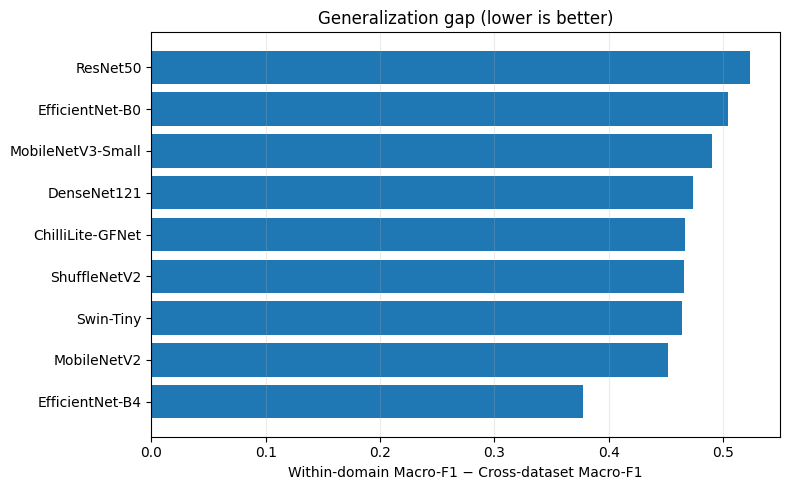

In [27]:

within = (
    summary[summary["experiment"] == "within_cv"]
    .groupby(["model_name", "model_display"])["test_macro_f1"]
    .mean()
    .rename("within_macro_f1")
)

cross = (
    summary[summary["experiment"] == "pairwise"]
    .groupby(["model_name", "model_display"])["test_macro_f1"]
    .mean()
    .rename("cross_macro_f1")
)

gap = pd.concat([within, cross], axis=1).dropna().reset_index()
gap["generalization_gap"] = gap["within_macro_f1"] - gap["cross_macro_f1"]
gap = gap.sort_values("generalization_gap")

if gap.empty:
    print("Need both within_cv and pairwise results.")
else:
    display(gap)
    gap.to_csv(TABLE_DIR / "generalization_gap.csv", index=False)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(gap["model_display"], gap["generalization_gap"])
    ax.set_xlabel("Within-domain Macro-F1 − Cross-dataset Macro-F1")
    ax.set_title("Generalization gap (lower is better)")
    ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()

    path = FIGURE_DIR / "generalization_gap.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print("Saved:", path)
    plt.show()



## 22. Export compact LaTeX tables

These exports can be inserted into the manuscript with `\input{...}` after review.


In [28]:

def export_latex_table(df, filename, index=False, float_format="%.4f"):
    path = TABLE_DIR / filename
    latex = df.to_latex(
        index=index,
        escape=True,
        float_format=float_format,
    )
    path.write_text(latex, encoding="utf-8")
    print("Saved:", path)


if not pairwise_table.empty:
    export_latex_table(
        pairwise_table,
        "pairwise_cross_dataset_results.tex",
        index=False,
    )

if not multisource_table.empty:
    export_latex_table(
        multisource_table,
        "multisource_results.tex",
        index=False,
    )

if not within_table.empty:
    export_latex_table(
        within_table,
        "within_cv_results.tex",
        index=False,
    )

if not pooled_table.empty:
    export_latex_table(
        pooled_table,
        "pooled_cv_results.tex",
        index=False,
    )


Saved: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_tables\pairwise_cross_dataset_results.tex
Saved: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_tables\multisource_results.tex
Saved: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_tables\within_cv_results.tex
Saved: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_tables\pooled_cv_results.tex



## 23. Final manuscript-ready checklist

Before copying tables or figures into the paper:

1. Confirm all intended models completed the same scenarios.
2. Confirm final seed counts are identical for paired statistical comparisons.
3. Report mean ± SD for repeated folds/seeds.
4. Use Macro-F1 and MCC as primary robustness metrics.
5. Use Holm-adjusted \(p\)-values for multiple comparisons.
6. Report effect sizes together with significance.
7. For the proposed model versus the strongest baseline, include:
   - exact McNemar test;
   - paired-bootstrap 95% CI.
8. Keep `exact_target_overlap_removed` in the audit trail.
9. State that SHA-256 detects exact duplicates only, not transformed near-duplicates.
10. Do not interpret pooled CV as external validation.


In [29]:

print("Analysis complete.")
print("Manuscript figures:", FIGURE_DIR)
print("Manuscript tables :", TABLE_DIR)


Analysis complete.
Manuscript figures: C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_figures
Manuscript tables : C:\Users\buntu\Desktop\tmp\PlantDisease\Chilli\CrossDataset_Leaf_Disease\first_attemp\results\manuscript_tables
